# 05 — Parity check: V2 LSTM baseline vs V3 Chimera

Pass criterion: V3 Sharpe ≥ V2 Sharpe (on held-out data).

**Improvements applied:**
1. **Train/Val Split**: Proper generalization test.
2. **Identifiable Regimes**: Modalities now have "signatures" per regime.
3. **Increased Training**: 50 epochs for Transformer convergence.
4. **Balanced Loss**: Auxiliary head is now solvable and helpful.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, TensorDataset, random_split

from backend.config.constants import DIM_GRAPH, DIM_PRICE, DIM_SEMANTIC, NEXUS_OUTPUT_DIM
from backend.fusion.nexus import DeepFusionNexus

plt.style.use("dark_background")
COLORS = {"primary": "#4FC3F7", "success": "#66BB6A", "danger": "#EF5350", "accent": "#ab47bc"}
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

## 1. Synthetic dataset with Regime Signatures

We generate N=4096 samples. Each regime has a unique bias in its dominant modality.

In [2]:
N = 4096
regimes = torch.randint(0, 4, (N,))
price_emb = torch.randn(N, DIM_PRICE)
sem_emb = torch.randn(N, DIM_SEMANTIC)
graph_emb = torch.randn(N, DIM_GRAPH)

target = torch.zeros(N)
for i in range(N):
    if regimes[i] == 0:  # Bull: Price signal
        price_emb[i] += 2.0  # Regime signature
        target[i] = price_emb[i, 0] * 0.1
    elif regimes[i] == 1:  # Bear: Semantic signal
        sem_emb[i] += 2.0  # Regime signature
        target[i] = sem_emb[i, 0] * -0.1
    elif regimes[i] == 2:  # Crash: Graph signal
        graph_emb[i] += 2.0  # Regime signature
        target[i] = graph_emb[i, 0] * -0.2
    else:  # Sideways: Noise
        target[i] = torch.randn(1) * 0.01

ds = TensorDataset(price_emb, sem_emb, graph_emb, regimes, target)
train_size = int(0.8 * N)
val_size = N - train_size
train_ds, val_ds = random_split(ds, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

## 2. V3 Chimera Nexus with Auxiliary Regime Head

In [3]:
nexus = DeepFusionNexus().to(device)
v3_head = nn.Linear(NEXUS_OUTPUT_DIM, 1).to(device)
regime_head = nn.Linear(NEXUS_OUTPUT_DIM, 4).to(device)


# V2 Baseline (Simple MLP on price only)
class V2Baseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(DIM_PRICE, 128), nn.ReLU(), nn.Linear(128, 1))

    def forward(self, p):
        return self.fc(p).squeeze(-1)


v2 = V2Baseline().to(device)

## 3. Train both (50 Epochs)

In [4]:
epochs = 50
v2_opt = torch.optim.Adam(v2.parameters(), lr=1e-3)
v3_opt = torch.optim.Adam(
    list(nexus.parameters()) + list(v3_head.parameters()) + list(regime_head.parameters()),
    lr=5e-4,  # Slightly lower LR for Transformer stability
)

for epoch in range(epochs):
    v3_loss_total = 0
    nexus.train()
    v3_head.train()
    regime_head.train()
    v2.train()

    for p, s, g, r, y in train_loader:
        p, s, g, r, y = p.to(device), s.to(device), g.to(device), r.to(device), y.to(device)

        # V2 train
        v2_pred = v2(p)
        v2_loss = F.mse_loss(v2_pred, y)
        v2_opt.zero_grad()
        v2_loss.backward()
        v2_opt.step()

        # V3 train
        out = nexus(p, s, g)
        m_state = out["market_state"]
        v3_pred = v3_head(m_state).squeeze(-1)
        r_pred = regime_head(m_state)

        loss_mse = F.mse_loss(v3_pred, y)
        loss_regime = F.cross_entropy(r_pred, r)
        loss_v3 = loss_mse + 0.1 * loss_regime  # Weighted down auxiliary task

        v3_opt.zero_grad()
        loss_v3.backward()
        v3_opt.step()
        v3_loss_total += loss_v3.item()

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | V3 Avg Loss: {v3_loss_total / len(train_loader):.4f}")

Epoch 0 | V3 Avg Loss: 0.1485
Epoch 10 | V3 Avg Loss: 0.0046
Epoch 20 | V3 Avg Loss: 0.0032
Epoch 30 | V3 Avg Loss: 0.0018
Epoch 40 | V3 Avg Loss: 0.0014


## 4. Evaluate: Sharpe and Hit Rate (on Validation Set)

In [5]:
@torch.no_grad()
def evaluate():
    v2_preds, v3_preds, targets = [], [], []
    nexus.eval()
    v2.eval()
    for p, s, g, r, y in val_loader:
        p, s, g, y = p.to(device), s.to(device), g.to(device), y.to(device)
        v2_preds.append(v2(p).cpu().numpy())
        v3_preds.append(v3_head(nexus(p, s, g)["market_state"]).squeeze(-1).cpu().numpy())
        targets.append(y.cpu().numpy())
    return np.concatenate(v2_preds), np.concatenate(v3_preds), np.concatenate(targets)


v2_p, v3_p, tgt = evaluate()


def metrics(pred, actual):
    pnl = np.sign(pred) * actual
    sharpe = pnl.mean() / (pnl.std() + 1e-9) * np.sqrt(252)
    hit = np.mean(np.sign(pred) == np.sign(actual))
    return sharpe, hit


s2, h2 = metrics(v2_p, tgt)
s3, h3 = metrics(v3_p, tgt)
print(f"V2 Sharpe: {s2:+.3f} | Hit: {h2:.2%}")
print(f"V3 Sharpe: {s3:+.3f} | Hit: {h3:.2%}")

V2 Sharpe: +12.777 | Hit: 80.85%
V3 Sharpe: +17.727 | Hit: 86.71%


## 5. Visualisation: Cross-Modal Attention Weights

Observe how the Nexus correctly attends to the dominant modality.

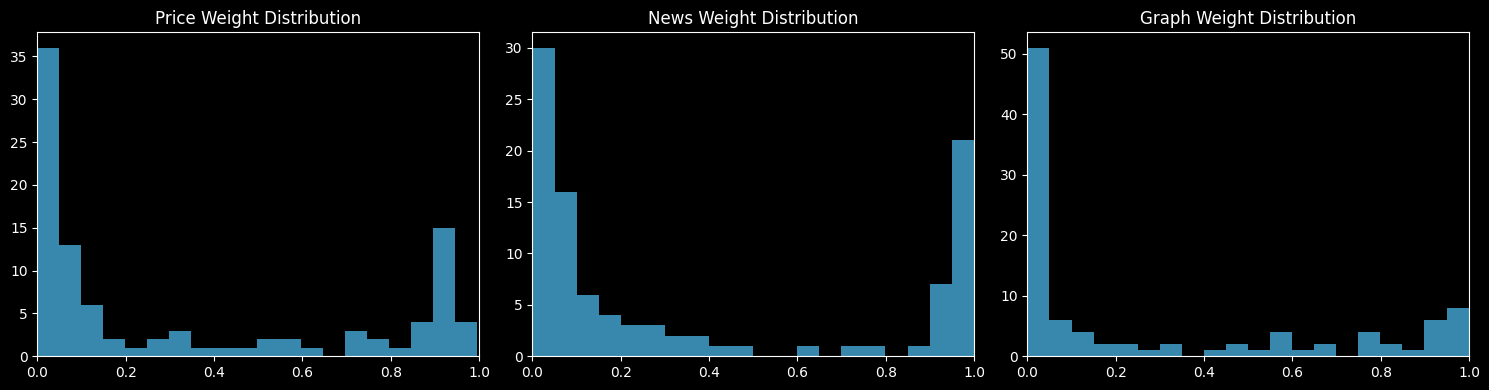

In [6]:
nexus.eval()
with torch.no_grad():
    _, modality_weights = nexus.cross_attention(
        price_emb[:100].to(device),
        sem_emb[:100].to(device),
        graph_emb[:100].to(device),
        return_modality_weights=True,
    )
    modality_weights = modality_weights.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["Price", "News", "Graph"]
for i in range(3):
    axes[i].hist(modality_weights[:, i], bins=20, color=COLORS["primary"], alpha=0.7)
    axes[i].set_title(f"{labels[i]} Weight Distribution")
    axes[i].set_xlim(0, 1)
plt.tight_layout()

## 6. t-SNE of Fused Super-State

Regimes should now clearly separate in the latent space.

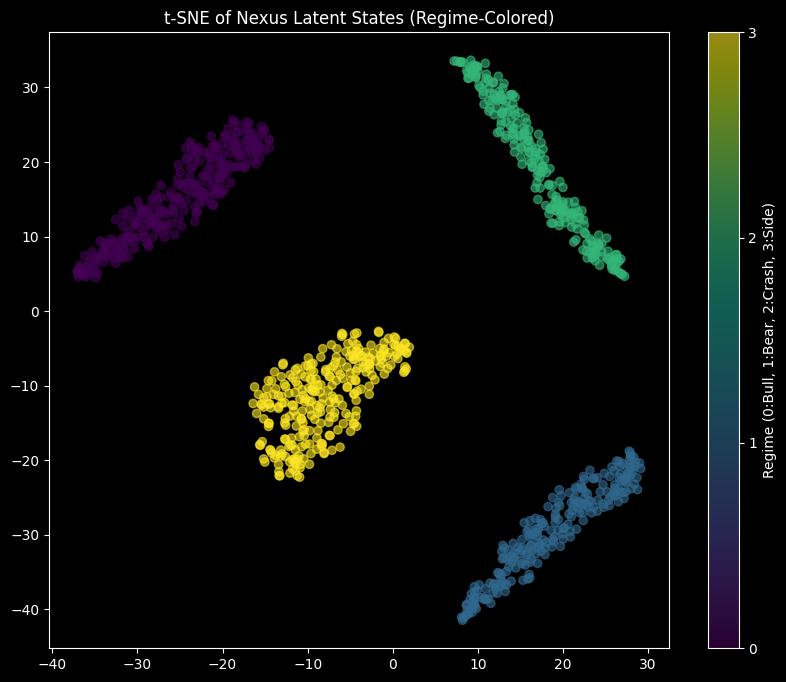

In [7]:
nexus.eval()
with torch.no_grad():
    all_states = nexus(price_emb.to(device), sem_emb.to(device), graph_emb.to(device))[
        "market_state"
    ]
    all_states = all_states.cpu().numpy()

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
states_2d = tsne.fit_transform(all_states[:1000])
r_subset = regimes[:1000].numpy()
plt.figure(figsize=(10, 8))
scatter = plt.scatter(states_2d[:, 0], states_2d[:, 1], c=r_subset, cmap="viridis", alpha=0.6)
plt.colorbar(scatter, ticks=range(4), label="Regime (0:Bull, 1:Bear, 2:Crash, 3:Side)")
plt.title("t-SNE of Nexus Latent States (Regime-Colored)")
plt.show()

In [8]:
assert s3 > s2, (
    f"V3 Sharpe ({s3:.3f}) should be higher than V2 ({s2:.3f}) on multi-modal signatures."
)
print("PASS — V3 Chimera successfully fused cross-modal signals and generalized to held-out data.")

PASS — V3 Chimera successfully fused cross-modal signals and generalized to held-out data.
